# PCA - 식습관 데이터를 차원 축소 시켜서 시각화하기
##### - 고차원 데이터를 1차원 데이터로 줄여서 시각화해보는 실습.
##### - 비지도학습

In [1]:
import pandas as pd

from sklearn import set_config
set_config(display="text")

## 데이터 획득
##### - 사람들의 하루 식습관 데이터를 만든 후, 주성분 분석을 통해서 데이터를 시각화해보도록 하겠음. 먼저 칼로리, 아침, 점심, 저녁, 운동 횟수, 그리고 체형이라는 특징을 가진 데이터 셋.

In [2]:
df = pd.DataFrame(columns=['calory', 'breakfast', 'lunch', 'dinner', 'exercise', 'body_shape'])

In [3]:
# 10명의 가공 데이터를 만듦.
# loc 컬럼

df.loc[0] = [1200, 1, 0, 0, 2, 'Skinny']
df.loc[1] = [2800, 1, 1, 1, 1, 'Normal']
df.loc[2] = [3500, 2, 2, 1, 0, 'Fat']
df.loc[3] = [1400, 0, 1, 0, 3, 'Skinny']
df.loc[4] = [5000, 2, 2, 2, 0, 'Fat']
df.loc[5] = [1300, 0, 0, 1, 2, 'Skinny']
df.loc[6] = [3000, 1, 0, 1, 1, 'Normal']
df.loc[7] = [4000, 2, 2, 2, 0, 'Fat']
df.loc[8] = [2600, 0, 2, 0, 0, 'Normal']
df.loc[9] = [3000, 1, 2, 1, 1, 'Fat']

In [4]:
df

,calory,breakfast,lunch,dinner,exercise,body_shape
0,1200,1,0,0,2,Skinny
1,2800,1,1,1,1,Normal
2,3500,2,2,1,0,Fat
3,1400,0,1,0,3,Skinny
4,5000,2,2,2,0,Fat
5,1300,0,0,1,2,Skinny
6,3000,1,0,1,1,Normal
7,4000,2,2,2,0,Fat
8,2600,0,2,0,0,Normal
9,3000,1,2,1,1,Fat


## 데이터 전처리
##### - 주성분 분석을 위해 데이터 전처리 과정이 필요함.
##### - 가공 데이터에 데이터 특징과 클래스가 함께 있으므로, 데이터의 특징만으로 구성된 데이터 프레임을 생성.

In [ ]:
# df = pd.DataFrame(columns=['calory', 'breakfast', 'lunch', 'dinner', 'exercise', 'body_shape'])

X = df[['calory', 'breakfast', 'lunch', 'dinner', 'exercise']]  # 학습 데이터, body_shape는 정답 데이터(label)
X

,calory,breakfast,lunch,dinner,exercise
0,1200,1,0,0,2
1,2800,1,1,1,1
2,3500,2,2,1,0
3,1400,0,1,0,3
4,5000,2,2,2,0
5,1300,0,0,1,2
6,3000,1,0,1,1
7,4000,2,2,2,0
8,2600,0,2,0,0
9,3000,1,2,1,1


In [6]:
Y = df[['body_shape']] # 정답 데이터
Y

,body_shape
0,Skinny
1,Normal
2,Fat
3,Skinny
4,Fat
5,Skinny
6,Normal
7,Fat
8,Normal
9,Fat


In [ ]:
# 표준화 : 다른 단위를 가진 측정값을 비교할 때, 분산을 극대화하는 성분에 관심이 있기 때문

from sklearn.preprocessing import StandardScaler



array([[-1.35205803,  0.        , -1.3764944 , -1.28571429,  1.        ],
       [ 0.01711466,  0.        , -0.22941573,  0.14285714,  0.        ],
       [ 0.61612771,  1.29099445,  0.91766294,  0.14285714, -1.        ],
       [-1.18091145, -1.29099445, -0.22941573, -1.28571429,  2.        ],
       [ 1.89972711,  1.29099445,  0.91766294,  1.57142857, -1.        ],
       [-1.26648474, -1.29099445, -1.3764944 ,  0.14285714,  1.        ],
       [ 0.18826125,  0.        , -1.3764944 ,  0.14285714,  0.        ],
       [ 1.04399418,  1.29099445,  0.91766294,  1.57142857, -1.        ],
       [-0.15403193, -1.29099445,  0.91766294, -1.28571429, -1.        ],
       [ 0.18826125,  0.        ,  0.91766294,  0.14285714,  0.        ]])

### scikit-learn을 사용한 주성분 분석 구현

In [ ]:
from sklearn import decomposition



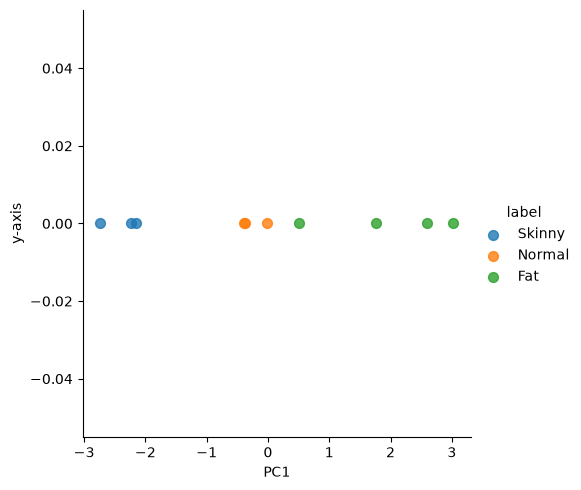

In [9]:
# 고차원 -> 1차원 시각화

import seaborn as sns

result = pd.DataFrame(pca_x, columns=['PC1'])
result['y-axis'] = 0.0
result['label'] = Y

sns.lmplot(x='PC1', y='y-axis', data=result, fit_reg=False,
           scatter_kws={"s":50},
           hue="label")